# Phase 3 - LLM-as-a-Judge Validation

**DOLPH-X Pipeline | Master 2 MIAGE**

**Description:** Automated quality validation of XAI explanations using a Large Language Model as evaluator. For each (instance, model) pair, the Judge receives the top-8 features by XAI importance and selects the 3 most reliable ones based on inter-method convergence and actionability.

**Model:** GPT-OSS 120B via Groq API (free tier)

**Note:** max_tokens=2000 is mandatory for this reasoning model (~700 tokens consumed internally before output).

**Input:** `outputs/lime_explanations.csv`, `outputs/mclime_explanations.csv`, `outputs/shap_explanations.csv`

**Output:** `outputs/validated_features.csv`

In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
os.makedirs('outputs', exist_ok=True)

os.environ['GROQ_API_KEY'] = 'XXX' 

try:
    from groq import Groq
    print('Groq import OK')
except ImportError:
    print('ERROR: Groq not installed - pip install groq')

print('\nChecking Phase 2 CSV files:')
for f in ['lime_explanations.csv', 'mclime_explanations.csv', 'shap_explanations.csv']:
    exists = os.path.exists(f'outputs/{f}')
    print(f'  {"OK" if exists else "MISSING"} {f}')

Groq import OK

Checking Phase 2 CSV files:
  OK lime_explanations.csv
  OK mclime_explanations.csv
  OK shap_explanations.csv


## 2. Load and Merge XAI Results

In [4]:
def load_and_merge_xai_results():

    print('LOADING XAI CSV FILES')
    print('=' * 50)

    df_lime = pd.read_csv('outputs/lime_explanations.csv')
    df_shap = pd.read_csv('outputs/shap_explanations.csv')
    df_mc   = pd.read_csv('outputs/mclime_explanations.csv')

    print(f'  LIME    : {len(df_lime)} rows, {df_lime["instance_id"].nunique()} instances')
    print(f'  SHAP    : {len(df_shap)} rows, {df_shap["instance_id"].nunique()} instances')
    print(f'  MC-LIME : {len(df_mc)} rows, {df_mc["instance_id"].nunique()} instances')

    # Load DiCE if available and non-empty
    dice_available = False
    try:
        df_dice = pd.read_csv('outputs/dice_explanations.csv')
        if len(df_dice) > 0:
            print(f'  DiCE    : {len(df_dice)} rows')
            dice_available = True
        else:
            print('  DiCE    : empty file - skipped (known limitation, see Section 2.3.5)')
    except Exception:
        print('  DiCE    : file not found - skipped')

    # Aggregate LIME scores by (instance_id, model, feature)
    df_lime_agg = df_lime.groupby(
        ['instance_id', 'model', 'profil', 'vrai_label', 'predit_label', 'feature']
    )['contribution'].mean().reset_index()
    df_lime_agg = df_lime_agg.rename(columns={'contribution': 'lime_score', 'profil': 'profil_reel'})

    # Aggregate SHAP scores
    df_shap_agg = df_shap.groupby(
        ['instance_id', 'model', 'feature']
    )['contribution'].mean().reset_index()
    df_shap_agg = df_shap_agg.rename(columns={'contribution': 'shap_score'})

    # Aggregate MC-LIME scores for the student actual profile only
    if 'classe_cible' in df_mc.columns and 'vrai_label' in df_mc.columns:
        df_mc_pred = df_mc[df_mc['classe_cible'] == df_mc['vrai_label']]
    else:
        df_mc_pred = df_mc
    df_mc_agg = df_mc_pred.groupby(
        ['instance_id', 'model', 'feature']
    )['contribution'].mean().reset_index()
    df_mc_agg = df_mc_agg.rename(columns={'contribution': 'mclime_score'})

    # Outer merge across all three methods
    df_merged = df_lime_agg.merge(
        df_shap_agg, on=['instance_id', 'model', 'feature'], how='outer'
    ).merge(
        df_mc_agg, on=['instance_id', 'model', 'feature'], how='outer'
    )

    # Add DiCE indicator if available
    if dice_available:
        df_dice_agg = df_dice.groupby(
            ['instance_id', 'model', 'feature']
        )['abs_delta'].mean().reset_index()
        df_dice_agg['dice_modifiee'] = df_dice_agg['abs_delta'] > 0
        df_merged = df_merged.merge(
            df_dice_agg[['instance_id', 'model', 'feature', 'dice_modifiee']],
            on=['instance_id', 'model', 'feature'], how='outer'
        )
    else:
        df_merged['dice_modifiee'] = False

    # Fill missing scores with 0
    df_merged['lime_score']    = df_merged['lime_score'].fillna(0)
    df_merged['shap_score']    = df_merged['shap_score'].fillna(0)
    df_merged['mclime_score']  = df_merged['mclime_score'].fillna(0)
    df_merged['dice_modifiee'] = df_merged['dice_modifiee'].fillna(False)

    # Propagate vrai_label and profil_reel by instance_id
    # (outer merge introduces NaN for rows coming from SHAP/MC-LIME only)
    df_merged['vrai_label'] = df_merged.groupby('instance_id')['vrai_label'].transform(
        lambda x: x.ffill().bfill()
    )
    df_merged['profil_reel'] = df_merged.groupby('instance_id')['profil_reel'].transform(
        lambda x: x.ffill().bfill()
    )
    # Fallback: use vrai_label if profil_reel is still NaN
    df_merged['profil_reel'] = df_merged['profil_reel'].fillna(df_merged['vrai_label'])

    print(f'\nConsolidated table: {len(df_merged)} rows')
    print(f'  Instances : {df_merged["instance_id"].nunique()}')
    print(f'  Models    : {list(df_merged["model"].unique())}')
    print(f'  Profiles  : {df_merged["profil_reel"].unique()}')
    print(f'  NaN profil_reel: {df_merged["profil_reel"].isna().sum()}')

    return df_merged

df_merged = load_and_merge_xai_results()

LOADING XAI CSV FILES
  LIME    : 220 rows, 13 instances
  SHAP    : 5950 rows, 13 instances
  MC-LIME : 1320 rows, 13 instances
  DiCE    : file not found - skipped

Consolidated table: 5950 rows
  Instances : 13
  Models    : ['Decision_Tree', 'Random_Forest', 'XGBoost']
  Profiles  : ['E-P+' 'E+P+' 'E-P-' 'E+P-']
  NaN profil_reel: 0


## 3. LLMJudge Class

For each (instance, model) pair, the Judge receives the top-8 features by mean absolute XAI importance and selects the 3 most reliable ones based on:
- **Inter-method convergence:** at least 2 out of 3 methods (LIME, SHAP, MC-LIME) agree on the sign
- **Actionability:** the student can concretely modify the feature
- **Confidence scoring rule:** 3/3 agreement = score >= 0.9 | 2/3 agreement = score 0.6-0.8

In [6]:
class LLMJudge:

    MODEL_NAME     = 'openai/gpt-oss-120b'
    TOP_N_FEATURES = 8
    API_DELAY      = 3.0

    def __init__(self, df_merged):
        self.df_merged = df_merged
        self.client    = Groq(api_key=os.environ.get('GROQ_API_KEY'))
        self.results   = []
        self.validated = []

    def _build_xai_table(self, instance_id, model_name):
        df = self.df_merged[
            (self.df_merged['instance_id'] == instance_id) &
            (self.df_merged['model']        == model_name)
        ].copy()

        if df.empty:
            return None

        # Global XAI importance: mean absolute score across all three methods
        df['importance'] = (
            df['lime_score'].abs() + df['shap_score'].abs() + df['mclime_score'].abs()
        ) / 3

        df_top     = df.nlargest(self.TOP_N_FEATURES, 'importance')
        profil     = df['profil_reel'].iloc[0] if 'profil_reel' in df.columns else '?'
        vrai_label = df['vrai_label'].iloc[0]  if 'vrai_label'  in df.columns else '?'
        if pd.isna(profil):     profil     = '?'
        if pd.isna(vrai_label): vrai_label = '?'

        features = []
        for _, row in df_top.iterrows():
            features.append({
                'name'  : row['feature'],
                'lime'  : round(float(row['lime_score']),   3),
                'shap'  : round(float(row['shap_score']),   3),
                'mclime': round(float(row['mclime_score']), 3),
            })

        return {
            'instance_id': instance_id, 'model': model_name,
            'profil': profil, 'vrai_label': vrai_label, 'features': features,
        }

    def _build_prompt(self, xai_data):
        FEAT_DESC = {
            'COURSE_ACCESS_MINUTES'    : 'time spent on platform (minutes)',
            'COURSE_ACCESS_CONNECTION' : 'number of logins to platform',
            'COURSE_INTERACTIONS'      : 'number of content interactions',
            'T_EXE_SUBMISSION_COUNT'   : 'total exercise submissions',
            'RATING_S5Q1'              : 'grade session 5',
            'RATING_S1Q1'              : 'grade session 1',
        }

        lines = '\n'.join([
            f"{i+1}. {f['name']} [{FEAT_DESC.get(f['name'], 'LMS variable')}] "
            f"(LIME={f['lime']:+.3f} SHAP={f['shap']:+.3f} MCLIME={f['mclime']:+.3f})"
            for i, f in enumerate(xai_data['features'])
        ])

        return (
            f"Profile: {xai_data['profil']}. Pick the 3 most reliable features "
            f"(2+ methods same sign, student-actionable).\n\n{lines}\n\n"
            "Rules:\n"
            "- confidence_score: 0.0 to 1.0 based on method agreement (3/3 = 0.9+, 2/3 = 0.6-0.8)\n"
            "- interpretation: short technical note in French, 5 words max, no direct address\n\n"
            'JSON only: {"f":[{"n":"name","s":0.85,"a":true,"i":"temps connexion faible"},'
            '{"n":"name","s":0.72,"a":true,"i":"peu de soumissions"},'
            '{"n":"name","s":0.61,"a":false,"i":"note S5 insuffisante"}],"main":"name","coh":0.80}'
        )

    def _call_llm(self, prompt):
        try:
            response = self.client.chat.completions.create(
                model=self.MODEL_NAME,
                messages=[
                    {'role': 'system', 'content': 'Output ONLY compact valid JSON. No text outside JSON. No markdown.'},
                    {'role': 'user',   'content': prompt}
                ],
                temperature=0.0,
                max_tokens=2000,
            )
            finish = response.choices[0].finish_reason
            raw    = response.choices[0].message.content

            if finish == 'length':
                print('\n    WARNING: truncated response')
                return None
            if not raw or len(raw.strip()) == 0:
                print('\n    WARNING: empty response')
                return None

            raw = raw.strip()
            if '```' in raw:
                raw = raw.split('```')[1].split('```')[0].strip()
                if raw.startswith('json'):
                    raw = raw[4:].strip()
            if '{' in raw and '}' in raw:
                raw = raw[raw.index('{'):raw.rindex('}')+1]
            else:
                print('\n    WARNING: no JSON found in response')
                return None

            return json.loads(raw)

        except json.JSONDecodeError as e:
            print(f'\n    ERROR: invalid JSON - {e}')
            return None
        except Exception as e:
            print(f'\n    ERROR: API call failed - {e}')
            return None

    def generate_judgments(self):
        print('\nGENERATING LLM JUDGMENTS')
        print('=' * 55)

        combinations = self.df_merged.groupby(
            ['instance_id', 'model']
        ).size().reset_index()[['instance_id', 'model']]

        # Priority order for model processing
        priority = {'XGBoost': 0, 'Random_Forest': 1, 'Decision_Tree': 2}
        combinations['order'] = combinations['model'].map(priority).fillna(3)
        combinations = combinations.sort_values(['instance_id', 'order'])

        print(f'Pairs to evaluate: {len(combinations)}')
        print(f'LLM model: {self.MODEL_NAME}\n')

        for _, row in combinations.iterrows():
            instance_id = int(row['instance_id'])
            model_name  = row['model']
            print(f'  Instance {instance_id:2d} | {model_name}...', end=' ', flush=True)

            xai_data = self._build_xai_table(instance_id, model_name)
            if xai_data is None:
                print('No data')
                continue

            response = self._call_llm(self._build_prompt(xai_data))

            if response and 'f' in response:
                self.results.append({
                    'instance_id': instance_id, 'model': model_name,
                    'profil': xai_data['profil'], 'vrai_label': xai_data['vrai_label'],
                    'llm_response': response,
                })
                n    = len(response.get('f', []))
                main = str(response.get('main', '?'))[:35]
                coh  = response.get('coh', 0)
                print(f'OK {n} features | main: {main} | coh: {float(coh):.2f}')
            else:
                print('FAILED')

            time.sleep(self.API_DELAY)

        print(f'\n{len(self.results)} judgments generated')

    def extract_validated_features(self):
        rows = []
        for result in self.results:
            response = result['llm_response']
            coh  = response.get('coh', 0)
            main = response.get('main', '')
            for feat in response.get('f', []):
                rows.append({
                    'instance_id'      : result['instance_id'],
                    'model'            : result['model'],
                    'profil'           : result['profil'],
                    'vrai_label'       : result['vrai_label'],
                    'feature'          : feat.get('n', ''),
                    'confidence_score' : feat.get('s', 0),
                    'actionable'       : feat.get('a', False),
                    'interpretation'   : feat.get('i', ''),
                    'is_main_feature'  : feat.get('n', '') == main,
                    'overall_coherence': coh,
                })
        self.validated = pd.DataFrame(rows)
        print(f'{len(self.validated)} validated features extracted')
        return self.validated

    def plot_results(self):
        if self.validated.empty:
            print('No results to visualise')
            return

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle('Phase 3 - LLM-as-a-Judge Results', fontsize=14, fontweight='bold')

        # Top 10 validated features
        ax = axes[0]
        top_feats = self.validated.groupby('feature')['confidence_score'].mean().sort_values(ascending=False).head(10)
        labels = [f[:25]+'...' if len(f)>25 else f for f in top_feats.index]
        ax.barh(range(len(top_feats)), top_feats.values, color='#1D9E75', alpha=0.8)
        ax.set_yticks(range(len(top_feats)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
        ax.set_title('Top 10 validated features')
        ax.grid(axis='x', alpha=0.3)

        # Confidence score distribution
        ax = axes[1]
        mean_s = self.validated['confidence_score'].mean()
        ax.hist(self.validated['confidence_score'], bins=15, color='#7F77DD', alpha=0.8, edgecolor='black')
        ax.axvline(mean_s, color='red', linestyle='--', label=f'Mean: {mean_s:.2f}')
        ax.set_title('Confidence score distribution')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # Mean coherence by profile
        ax = axes[2]
        coh = self.validated.groupby('profil')['overall_coherence'].mean().sort_values(ascending=True)
        colors = ['#1D9E75' if v >= 0.5 else '#D85A30' for v in coh.values]
        ax.barh(range(len(coh)), coh.values, color=colors, alpha=0.8)
        ax.set_yticks(range(len(coh)))
        ax.set_yticklabels(coh.index)
        ax.axvline(0.5, color='red', linestyle='--', alpha=0.5)
        ax.set_title('Mean coherence by profile')
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.savefig('outputs/phase3_llm_judge_results.png', dpi=150, bbox_inches='tight')
        plt.show()

    def export(self, filename='outputs/validated_features.csv'):
        if self.validated.empty:
            print('No validated features to export')
            return
        self.validated.to_csv(filename, index=False)
        print(f'\nExport complete: {filename}')
        print(f'  {len(self.validated)} rows | {self.validated["instance_id"].nunique()} instances')
        return self.validated

    def run(self):
        print('STARTING LLM-AS-A-JUDGE PIPELINE')
        print('=' * 70)
        self.generate_judgments()
        self.extract_validated_features()
        self.plot_results()
        self.export()
        print('\nPHASE 3 PIPELINE COMPLETE')
        print('-> Next: 04_phase4_feedback.ipynb')

## 4. Execution

In [14]:
judge = LLMJudge(df_merged)
judge.run()

STARTING LLM-AS-A-JUDGE PIPELINE

GENERATING LLM JUDGMENTS
Pairs to evaluate: 35
LLM model: openai/gpt-oss-120b

  Instance  0 | XGBoost... OK 3 features | main: FIRST_S8Q1_EXE_SUBMISSION_day | coh: 0.74
  Instance  0 | Random_Forest... OK 3 features | main: FIRST_S8Q1_EXE_SUBMISSION_day | coh: 0.69
  Instance  0 | Decision_Tree... OK 3 features | main: FIRST_S8Q1_EXE_SUBMISSION_day | coh: 0.73
  Instance  1 | XGBoost... OK 3 features | main: FIRST_S8Q1_EXE_SUBMISSION_day | coh: 0.75
  Instance  1 | Random_Forest... OK 3 features | main: FIRST_S8Q1_EXE_SUBMISSION_day | coh: 0.75
  Instance  5 | XGBoost... OK 3 features | main: COURSE_ACCESS_CONNECTION | coh: 0.73
  Instance  5 | Random_Forest... OK 3 features | main: COURSE_ACCESS_CONNECTION | coh: 0.86
  Instance  5 | Decision_Tree... OK 3 features | main: COURSE_ACCESS_CONNECTION | coh: 0.72
  Instance  7 | XGBoost... OK 3 features | main: COURSE_ACCESS_MINUTES | coh: 0.75
  Instance  7 | Random_Forest... OK 3 features | main: COURSE

KeyboardInterrupt: 

## 5. Results Analysis

In [16]:
df_validated = pd.read_csv('outputs/validated_features.csv')
print(f'Shape              : {df_validated.shape}')
print(f'Profiles           : {df_validated["profil"].unique()}')
print(f'Models             : {df_validated["model"].unique()}')
print(f'Mean confidence    : {df_validated["confidence_score"].mean():.2f}')
df_validated.head(10)

Shape              : (105, 10)
Profiles           : ['E-P+' 'E+P+' 'E-P-' 'E+P-']
Models             : ['XGBoost' 'Random_Forest' 'Decision_Tree']
Mean confidence    : 0.75


,instance_id,model,profil,vrai_label,feature,confidence_score,actionable,interpretation,is_main_feature,overall_coherence
0,0,XGBoost,E-P+,E-P+,FIRST_S8Q1_EXE_SUBMISSION_day,0.75,True,soumission précoce améliore performance,True,0.73
1,0,XGBoost,E-P+,E-P+,FIRST_S7Q1_EXE_SUBMISSION_day,0.73,True,soumission rapide augmente réussite,False,0.73
2,0,XGBoost,E-P+,E-P+,FIRST_S1Q1_EXE_SUBMISSION_second,0.71,True,soumission rapide favorise note,False,0.73
3,0,Random_Forest,E-P+,E-P+,FIRST_S8Q1_EXE_SUBMISSION_day,0.78,True,soumissions tardives pénalisent,True,0.74
4,0,Random_Forest,E-P+,E-P+,LAST_S8Q1_EXE_SUBMISSION_day,0.73,True,soumissions récentes favorisent,False,0.74
5,0,Random_Forest,E-P+,E-P+,RATING_S5Q1,0.70,False,note S5 faible impact,False,0.74
6,0,Decision_Tree,E-P+,E-P+,RATING_S5Q1,0.78,True,note session cinq faible,True,0.73
7,0,Decision_Tree,E-P+,E-P+,COURSE_ACCESS_MINUTES,0.72,True,temps plateforme insuffisant,False,0.73
8,0,Decision_Tree,E-P+,E-P+,FIRST_S8Q1_EXE_SUBMISSION_day,0.68,True,soumissions tardives fréquentes,False,0.73
9,1,XGBoost,E-P+,E-P+,FIRST_S8Q1_EXE_SUBMISSION_day,0.70,True,soumission tardive augmente risque,True,0.70


In [18]:
# Main feature per profile (highest mean confidence score among main features)
print('MAIN FEATURES PER PROFILE')
print('=' * 50)
for profil in df_validated['profil'].unique():
    df_p = df_validated[
        (df_validated['profil']         == profil) &
        (df_validated['is_main_feature'] == True)
    ]
    if not df_p.empty:
        top    = df_p.groupby('feature')['confidence_score'].mean().idxmax()
        score  = df_p.groupby('feature')['confidence_score'].mean().max()
        interp = df_p[df_p['feature'] == top]['interpretation'].iloc[0]
        print(f'\n{profil} -> {top} (confidence: {score:.2f})')
        print(f'  Note: {interp}')

MAIN FEATURES PER PROFILE

E-P+ -> COURSE_ACCESS_CONNECTION (confidence: 0.95)
  Note: faible nombre de connexions

E+P+ -> LAST_S5Q1_EXE_SUBMISSION_month (confidence: 0.87)
  Note: soumissions tardives mois

E-P- -> COURSE_ACCESS_MINUTES (confidence: 0.76)
  Note: temps plateforme faible

E+P- -> COURSE_ACCESS_MINUTES (confidence: 0.84)
  Note: temps de connexion élevé


In [20]:
# Detailed view for a specific (instance, model) pair
instance_voulu = df_validated['instance_id'].iloc[0]
model_voulu    = 'Random_Forest'

subset = df_validated[
    (df_validated['instance_id'] == instance_voulu) &
    (df_validated['model']        == model_voulu)
]

if not subset.empty:
    print(f'=== Instance {instance_voulu} | {model_voulu} | Profile {subset["profil"].iloc[0]} ===')
    for _, row in subset.iterrows():
        flag = '[MAIN]' if row['is_main_feature'] else ''
        print(f'  {row["feature"]:<45} score={row["confidence_score"]:.2f} {flag}')
        print(f'  Note: {row["interpretation"]}')
else:
    print('No data for this combination')

=== Instance 0 | Random_Forest | Profile E-P+ ===
  FIRST_S8Q1_EXE_SUBMISSION_day                 score=0.78 [MAIN]
  Note: soumissions tardives pénalisent
  LAST_S8Q1_EXE_SUBMISSION_day                  score=0.73 
  Note: soumissions récentes favorisent
  RATING_S5Q1                                   score=0.70 
  Note: note S5 faible impact


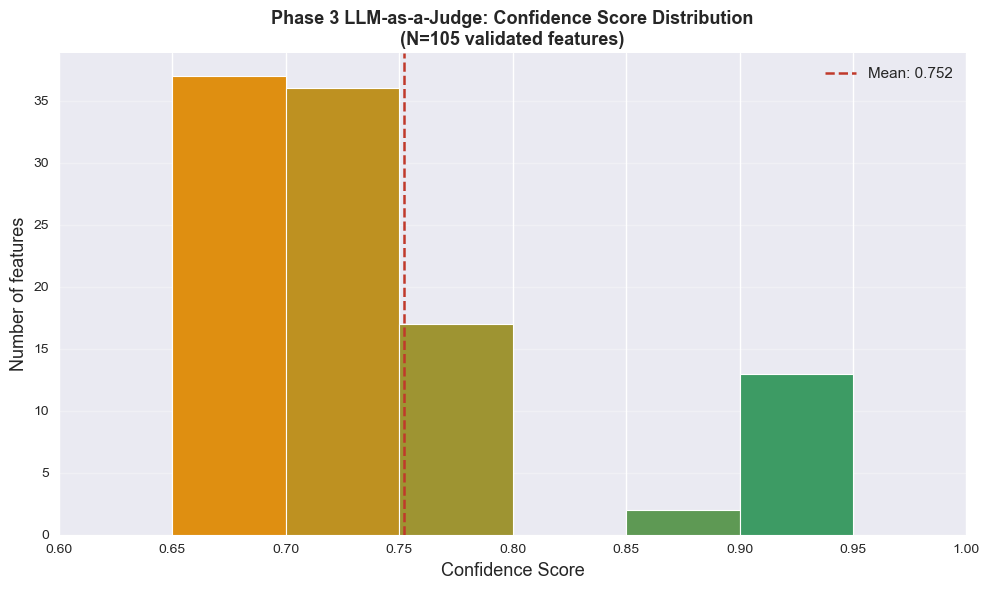

In [24]:
import matplotlib.colors as mcolors

df_validated = pd.read_csv('outputs/validated_features.csv')
mean_score   = df_validated['confidence_score'].mean()
bins = np.arange(0.60, 1.01, 0.05)
cmap = mcolors.LinearSegmentedColormap.from_list('rel', ['#FF8C00', '#1D9E75'], N=len(bins)-1)

fig, ax = plt.subplots(figsize=(10, 6))
n, edges, patches = ax.hist(df_validated['confidence_score'], bins=bins,
                             edgecolor='white', linewidth=0.8)
for patch, color in zip(patches, cmap(np.linspace(0, 1, len(patches)))):
    patch.set_facecolor(color)
ax.axvline(mean_score, color='#C0392B', linestyle='--', linewidth=1.8,
           label=f'Mean: {mean_score:.3f}')
ax.set_xlabel('Confidence Score', fontsize=13)
ax.set_ylabel('Number of features', fontsize=13)
ax.set_title('Phase 3 LLM-as-a-Judge: Confidence Score Distribution\n(N=105 validated features)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0.60, 1.00); ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/canva/fig_confidence_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

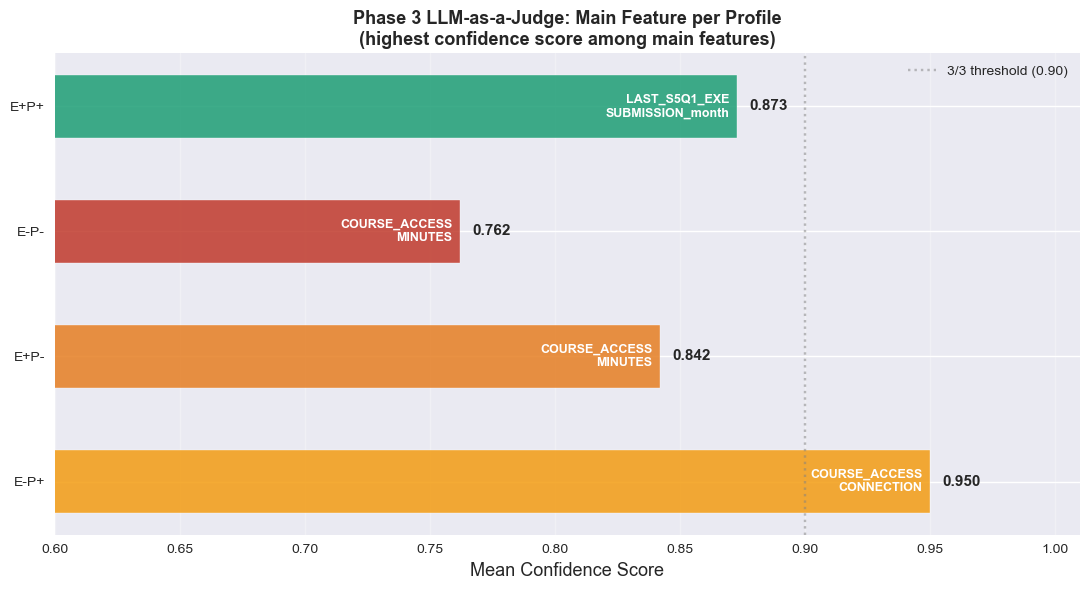

In [26]:
df_validated = pd.read_csv('outputs/validated_features.csv')

profiles  = ['E-P+', 'E+P-', 'E-P-', 'E+P+']
features  = ['COURSE_ACCESS\nCONNECTION', 'COURSE_ACCESS\nMINUTES',
             'COURSE_ACCESS\nMINUTES', 'LAST_S5Q1_EXE\nSUBMISSION_month']
scores    = [0.950, 0.842, 0.762, 0.873]
colors_p  = ['#F39C12', '#E67E22', '#C0392B', '#1D9E75']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(profiles, scores, color=colors_p, alpha=0.85, edgecolor='white', height=0.5)
for bar, feat, score in zip(bars, features, scores):
    ax.text(score - 0.003, bar.get_y() + bar.get_height()/2,
            feat, va='center', ha='right', fontsize=9, color='white', fontweight='bold')
    ax.text(score + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', ha='left', fontsize=11, fontweight='bold')
ax.set_xlim(0.60, 1.01)
ax.set_xlabel('Mean Confidence Score', fontsize=13)
ax.set_title('Phase 3 LLM-as-a-Judge: Main Feature per Profile\n(highest confidence score among main features)',
             fontsize=13, fontweight='bold')
ax.axvline(0.9, color='gray', linestyle=':', alpha=0.5, label='3/3 threshold (0.90)')
ax.legend(fontsize=10); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/canva/fig_main_features_profile.png', dpi=200, bbox_inches='tight')
plt.show()